In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


In [4]:
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [5]:
df.describe()

,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,21.494000,5.407333,3.256853,3.344587,8.51000,5.417333
std,2.297277,2.905462,0.430583,0.437409,4.07148,2.844977
min,18.000000,1.000000,2.500000,2.400000,2.00000,1.000000
25%,20.000000,3.000000,2.880000,2.980000,5.00000,3.000000
50%,21.000000,5.000000,3.260000,3.360000,9.00000,5.000000
75%,23.000000,8.000000,3.620000,3.710000,12.00000,8.000000
max,25.000000,10.000000,4.000000,4.000000,15.00000,10.000000


In [6]:
df.isnull().sum()

Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64

In [7]:
df["GPA_Change"]=df["GPA_Post_AI"]-df["GPA_Baseline"]

In [8]:
df["Usage_Level"]=pd.cut(df["Task_Frequency_Daily"], bins=[0,2,5,10], labels=["Low","Medium","High"])

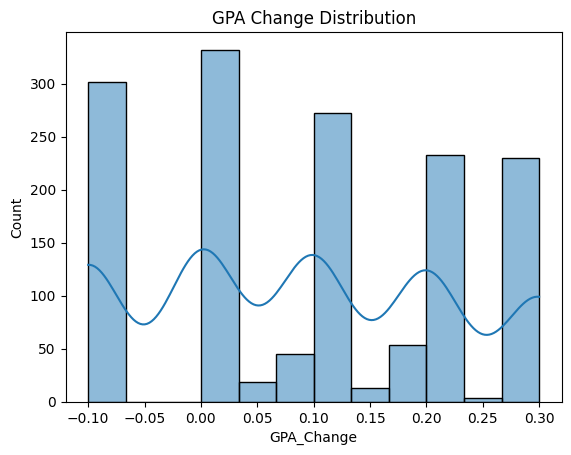

In [9]:
sns.histplot(df["GPA_Change"], kde=True)
plt.title("GPA Change Distribution")
plt.show()

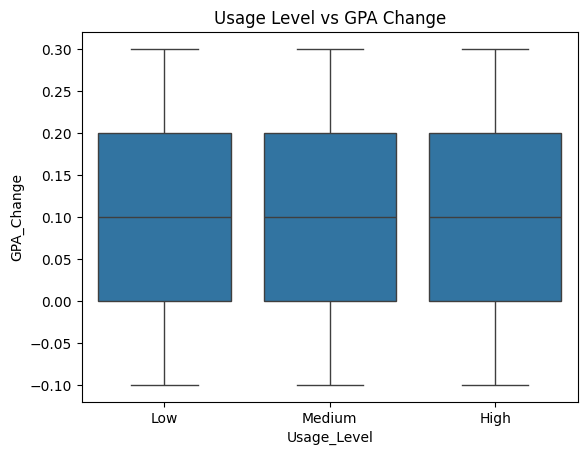

In [10]:
sns.boxplot(x="Usage_Level", y="GPA_Change", data=df)
plt.title("Usage Level vs GPA Change")
plt.show()

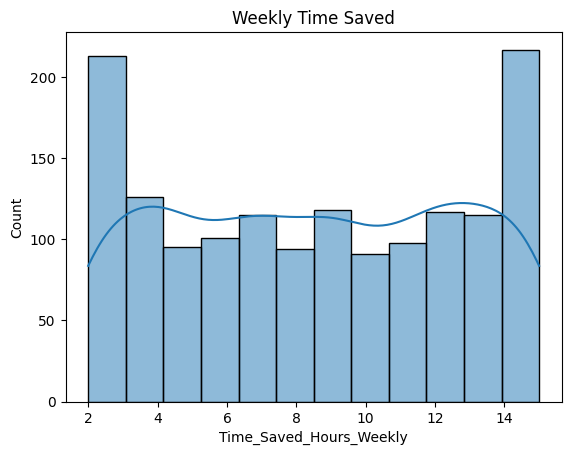

In [11]:
sns.histplot(df["Time_Saved_Hours_Weekly"], kde=True)
plt.title("Weekly Time Saved")
plt.show()

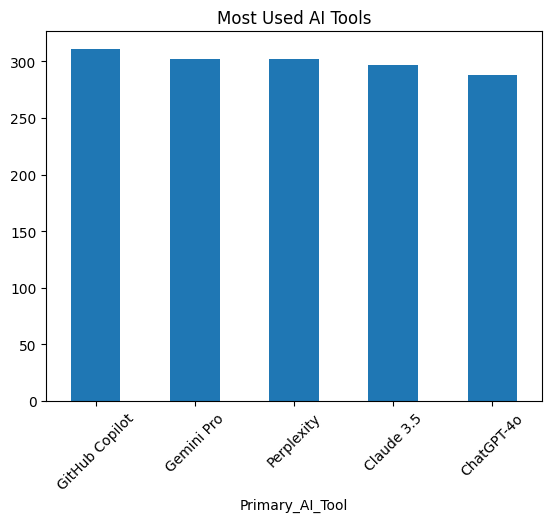

In [12]:
df["Primary_AI_Tool"].value_counts().plot(kind="bar")
plt.title("Most Used AI Tools")
plt.xticks(rotation=45)
plt.show()

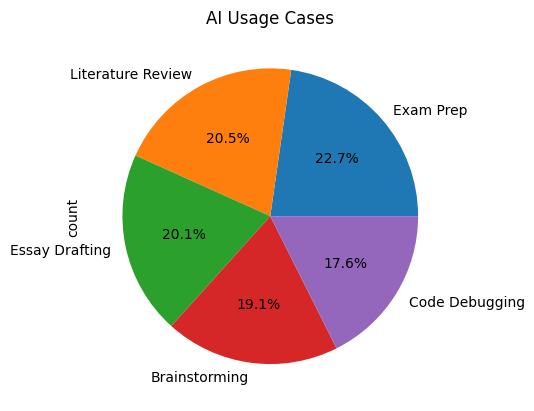

In [13]:
df["Main_Usage_Case"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("AI Usage Cases")
plt.show()

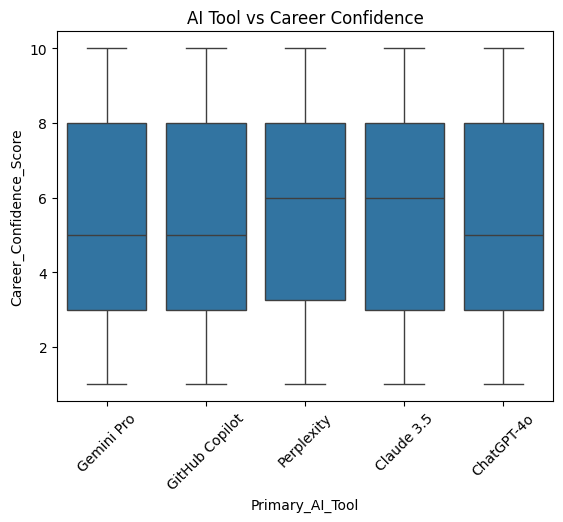

In [14]:
sns.boxplot(x="Primary_AI_Tool", y="Career_Confidence_Score", data=df)
plt.xticks(rotation=45)
plt.title("AI Tool vs Career Confidence")
plt.show()

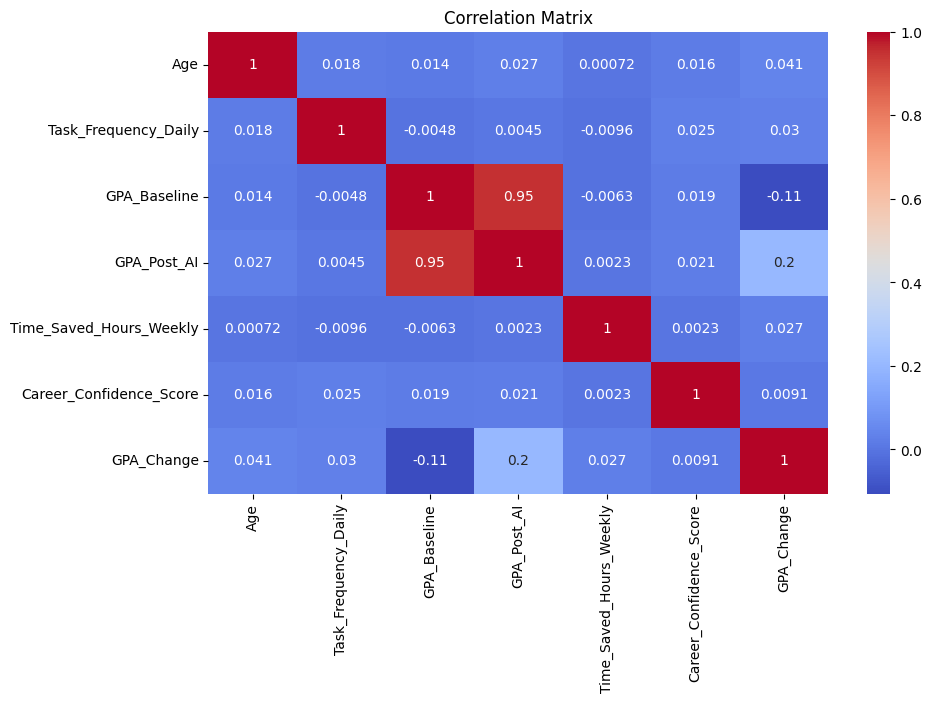

In [15]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

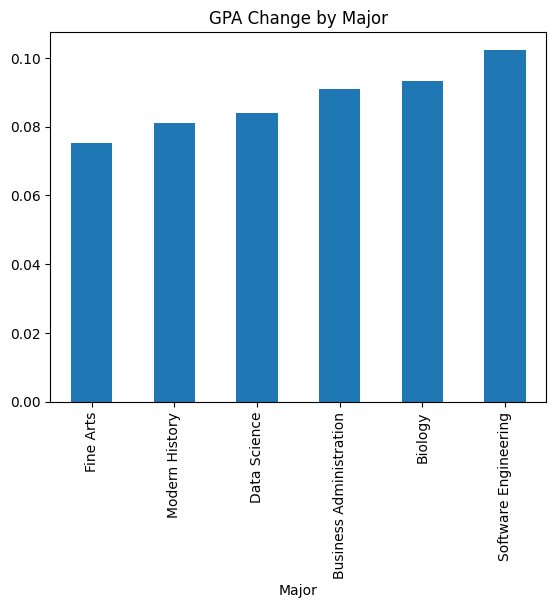

In [16]:
df.groupby("Major")["GPA_Change"].mean().sort_values().plot(kind="bar")
plt.title("GPA Change by Major")
plt.show()

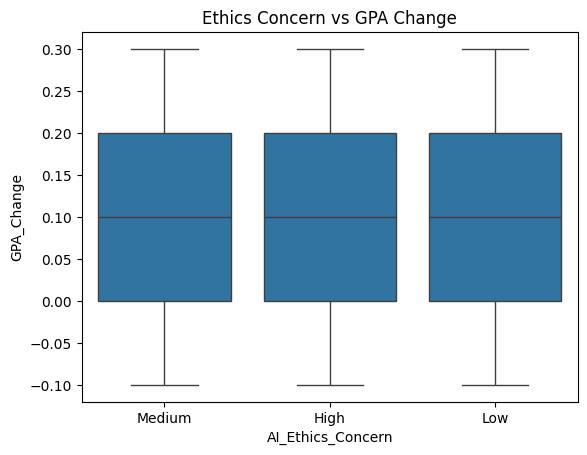

In [17]:
sns.boxplot(x="AI_Ethics_Concern", y="GPA_Change", data=df)
plt.title("Ethics Concern vs GPA Change")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_ml=df.copy()

categorical_cols=["Major", "Primary_AI_Tool", "Main_Usage_Case", "AI_Ethics_Concern", "Usage_Level"]

le=LabelEncoder()
for col in categorical_cols:
    df_ml[col]=le.fit_transform(df_ml[col])

X=df_ml.drop(["Student_ID", "GPA_Change"], axis=1)
y=df_ml["GPA_Change"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model=RandomForestRegressor()
model.fit(X_train, y_train)

print("Model Score:", model.score(X_test, y_test))

Model Score: 0.9895147957615811


Key Findings

* AI tools significantly improved students' GPA on average
* Higher daily AI usage correlates with greater GPA improvement
* Students save substantial time weekly using AI tools
* Career confidence tends to increase with AI adoption
* Ethical concerns slightly reduce the effectiveness of AI usage